In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso,Ridge,ElasticNet
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.pipeline import Pipeline 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("encoded_car_data (1).csv")
print(data.head())

   diesel  gas  std  turbo  convertible  hardtop  hatchback  sedan  wagon  \
0     0.0  1.0  1.0    0.0          1.0      0.0        0.0    0.0    0.0   
1     0.0  1.0  1.0    0.0          1.0      0.0        0.0    0.0    0.0   
2     0.0  1.0  1.0    0.0          0.0      0.0        1.0    0.0    0.0   
3     0.0  1.0  1.0    0.0          0.0      0.0        0.0    1.0    0.0   
4     0.0  1.0  1.0    0.0          0.0      0.0        0.0    1.0    0.0   

   4wd  ...  wheelbase  curbweight  enginesize  boreratio  horsepower  \
0  0.0  ...       88.6      2548.0       130.0       3.47       111.0   
1  0.0  ...       88.6      2548.0       130.0       3.47       111.0   
2  0.0  ...       94.5      2823.0       152.0       2.68       154.0   
3  0.0  ...       99.8      2337.0       109.0       3.19       102.0   
4  1.0  ...       99.4      2824.0       136.0       3.19       115.0   

   carlength  carwidth  citympg  highwaympg    price  
0      168.8      64.1     21.0        27.0

In [3]:
data=pd.get_dummies(data,drop_first=True)

In [4]:
x=data.drop('price',axis=1)
y=data['price']

In [5]:
scaler=StandardScaler()
x=scaler.fit_transform(x)
y=scaler.fit_transform(y.values.reshape(-1,1))


In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
models={
    "Ridge":Ridge(alpha=1.0),
    "Lasso":Lasso(alpha=1.0),
    "ElasticNet":ElasticNet(alpha=1.0,l1_ratio=0.5)
}

In [8]:
results={}

In [9]:
for name, model in models.items():
    pipeline=Pipeline([
        ('poly',PolynomialFeatures(degree=2)),
        ('regressor',model)
    ])

In [10]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('poly', PolynomialFeatures()), ('regressor', ElasticNet())])

In [11]:
predictions=pipeline.predict(x_test)

In [12]:
mse=mean_squared_error(y_test,predictions)
r2=r2_score(y_test,predictions)
mae=mean_absolute_error(y_test,predictions)

In [13]:
results[name]={'MSE':mse,'R^2 Score':r2,'MAE':mae}

In [14]:
print("Name: Lakshiya Rajkumar")
print("Reg No: 212225240076")

for model_name, metrics in results.items():
    print(f"{model_name} - Mean Squared Error: {metrics ['MSE']:.2f}, R^2 Score: {metrics['R^2 Score']:.2f}")

Name: Lakshiya Rajkumar
Reg No: 212225240076
ElasticNet - Mean Squared Error: 0.63, R^2 Score: 0.49


In [15]:
results_df = pd.DataFrame (results).T
results_df.reset_index(inplace=True)
results_df.rename(columns={'index': 'Model'}, inplace=True)

In [16]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

(array([0]), [Text(0, 0, 'ElasticNet')])

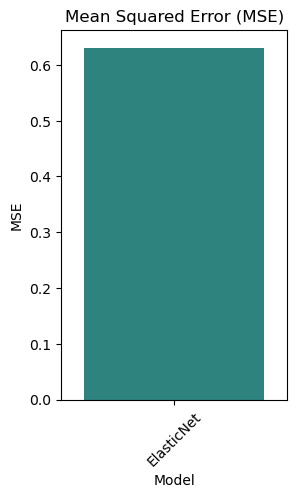

In [17]:
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='MSE', data=results_df, palette='viridis')
plt.title('Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xticks (rotation=45)

(array([0]), [Text(0, 0, 'ElasticNet')])

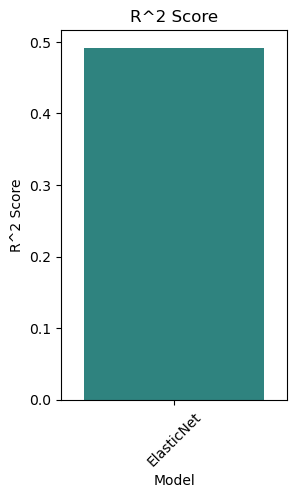

In [18]:
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R^2 Score', data=results_df, palette='viridis')
plt.title('R^2 Score')
plt.ylabel('R^2 Score')
plt.xticks (rotation=45)


In [19]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>